# Kryptografie založená na mřížkách: Vizualizace dobrých a špatných bází

Tento notebook demonstruje fundamentální koncept kvality bází v kryptografii založené na mřížkách a jejich vliv na problém nejbližšího vektoru (Closest Vector Problem - CVP).

## Přehled

V kryptografii založené na mřížkách je **kvalita báze** klíčovým konceptem. Stejná mřížka může být reprezentována různými bázemi:
- **Dobrá báze**: Krátké, téměř ortogonální vektory - umožňuje snadné řešení problémů
- **Špatná báze**: Dlouhé, zkosené vektory - činí problémy výpočetně náročnými

Tato asymetrie tvoří základ bezpečnosti postkvantových kryptografických schémat jako NTRU a Learning With Errors (LWE).

## Import potřebných knihoven

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib import patches
import warnings
warnings.filterwarnings('ignore')

# Nastavení náhodného seedu pro reprodukovatelnost
np.random.seed(42)

print("Knihovny úspěšně naimportovány!")

Knihovny úspěšně naimportovány!


## Definice dobré a špatné báze

**Dobrá báze** se skládá z téměř ortogonálních, krátkých vektorů.

**Špatná báze** je získána aplikací unimodulární transformace (determinant ±1) na dobrou bázi, což vede k dlouhým, zkoseným vektorům, které generují tutéž mřížku.

In [47]:
# Definice dobré báze (téměř ortogonální, krátké vektory)
B_good = np.array([[1, 0], 
                   [0, 1]], dtype=float)

# Definice unimodulární matice (det = ±1, celočíselné prvky)
# Zachovává mřížku, ale vytváří špatnou bázi
U = np.array([[15, 7], 
              [13, 6]], dtype=float)

# Ověření unimodulární vlastnosti
det_U = np.linalg.det(U)
print(f"Determinant matice U: {det_U}")
print(f"U je unimodulární: {np.isclose(abs(det_U), 1.0, atol=1e-8)}")

# Vytvoření špatné báze násobením U * B_good
B_bad = U @ B_good

print("\n=== Dobrá báze ===")
print(B_good)
print(f"Délky vektorů: {np.linalg.norm(B_good[0]):.2f}, {np.linalg.norm(B_good[1]):.2f}")
print(f"Ortogonalita (skalární součin): {np.dot(B_good[0], B_good[1]):.2f}")

print("\n=== Špatná báze ===")
print(B_bad)
print(f"Délky vektorů: {np.linalg.norm(B_bad[0]):.2f}, {np.linalg.norm(B_bad[1]):.2f}")
print(f"Ortogonalita (skalární součin): {np.dot(B_bad[0], B_bad[1]):.2f}")

Determinant matice U: -0.9999999999999964
U je unimodulární: True

=== Dobrá báze ===
[[1. 0.]
 [0. 1.]]
Délky vektorů: 1.00, 1.00
Ortogonalita (skalární součin): 0.00

=== Špatná báze ===
[[15.  7.]
 [13.  6.]]
Délky vektorů: 16.55, 14.32
Ortogonalita (skalární součin): 237.00


## Funkce pro generování bodů mřížky

Generuje všechny body mřížky v zadaném rozsahu pomocí celočíselných lineárních kombinací bázových vektorů.

In [48]:
def generate_lattice_points(basis, range_limit=5, bounds=None):
    """
    Generování bodů mřížky jako celočíselných lineárních kombinací bázových vektorů.
    
    Parametry:
    -----------
    basis : numpy.ndarray
        Matice 2x2 reprezentující bázi mřížky
    range_limit : int
        Maximální rozsah koeficientů pro lineární kombinace
    bounds : tuple, optional
        (x_min, x_max, y_min, y_max) – filtrování bodů do zadaných mezí
    
    Návratová hodnota:
    ------------------
    numpy.ndarray
        Matice Nx2 s body mřížky
    """
    i_vals = np.arange(-range_limit, range_limit + 1)
    j_vals = np.arange(-range_limit, range_limit + 1)
    ii, jj = np.meshgrid(i_vals, j_vals)
    points = ii.ravel()[:, np.newaxis] * basis[0] + jj.ravel()[:, np.newaxis] * basis[1]
    if bounds is not None:
        x_min, x_max, y_min, y_max = bounds
        mask = ((points[:, 0] >= x_min) & (points[:, 0] <= x_max) &
                (points[:, 1] >= y_min) & (points[:, 1] <= y_max))
        points = points[mask]
    return points

# Test funkce
test_points = generate_lattice_points(B_good, range_limit=2)
print(f"Vygenerováno {len(test_points)} bodů mřížky")


Vygenerováno 25 bodů mřížky


## Funkce pro vykreslení mřížky

Vytvoří profesionální vizualizaci zobrazující:
- Body mřížky (tečky)
- Bázové vektory (šipky)
- Fundamentální rovnoběžník (stínovaná oblast)

In [49]:
def plot_lattice(basis, basis_name, range_limit=5, target=None, closest_point=None, ax=None):
    """
    Vykreslení 2D mřížky s bázovými vektory a fundamentálním rovnoběžníkem.
    
    Parametry:
    -----------
    basis : numpy.ndarray
        Matice 2x2 reprezentující bázi
    basis_name : str
        Název báze pro titulek grafu
    range_limit : int
        Minimální rozsah koeficientů (automaticky zvýšen pro pokrytí celé osy)
    target : numpy.ndarray, optional
        Cílový bod k vykreslení
    closest_point : numpy.ndarray, optional
        Nejbližší bod mřížky k zvýraznění
    ax : matplotlib.axes.Axes, optional
        Osa matplotlib (pokud None, vytvoří nový obrázek)
    
    Návratová hodnota:
    ------------------
    matplotlib.axes.Axes
        Osa s vykresleným grafem
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    # Bílé pozadí, čisté spiny
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
        spine.set_linewidth(1.2)

    # Automatický výpočet range_limit tak, aby pokryl celou vykreslovanou oblast
    plot_bound = 20
    try:
        basis_inv = np.linalg.inv(basis)
        corners = np.array([[plot_bound, plot_bound], [plot_bound, -plot_bound],
                             [-plot_bound, plot_bound], [-plot_bound, -plot_bound]])
        corner_coeffs = (basis_inv @ corners.T).T
        auto_range = int(np.ceil(np.max(np.abs(corner_coeffs)))) + 1
    except np.linalg.LinAlgError:
        auto_range = range_limit
    range_limit = max(range_limit, auto_range)

    # Generování bodů mřížky s filtrací do vykreslované oblasti
    lattice_points = generate_lattice_points(
        basis, range_limit, bounds=(-plot_bound, plot_bound, -plot_bound, plot_bound)
    )

    # Vykreslení bodů mřížky
    ax.scatter(lattice_points[:, 0], lattice_points[:, 1],
               c='#4C9BE8', s=35, alpha=0.75, zorder=2, linewidths=0, label='Body mřížky')

    # Zvýraznění počátku
    ax.scatter([0], [0], c='#222222', s=120, marker='o', zorder=5, label='Počátek')

    # Velikost hlavičky šipky fixní v datových jednotkách – viditelná i pro krátké vektory
    hw = plot_bound * 0.035   # head_width  ≈ 0.7 pro plot_bound=20
    hl = plot_bound * 0.04    # head_length ≈ 0.8 pro plot_bound=20

    ax.arrow(0, 0, basis[0, 0], basis[0, 1],
             head_width=hw, head_length=hl,
             fc='#E03030', ec='#E03030', linewidth=2.0,
             length_includes_head=True, zorder=4)
    ax.plot([], [], color='#E03030', linewidth=2.0, label='Bázový vektor $b_1$')

    ax.arrow(0, 0, basis[1, 0], basis[1, 1],
             head_width=hw, head_length=hl,
             fc='#27A727', ec='#27A727', linewidth=2.0,
             length_includes_head=True, zorder=4)
    ax.plot([], [], color='#27A727', linewidth=2.0, label='Bázový vektor $b_2$')

    # Vykreslení fundamentálního rovnoběžníku
    parallelepiped = np.array([
        [0, 0],
        basis[0],
        basis[0] + basis[1],
        basis[1],
    ])

    poly = Polygon(parallelepiped, alpha=0.35, facecolor='#FFA500',
                   edgecolor='#CC7700', linewidth=2, zorder=1, label='Fundamentální rovnoběžník')
    ax.add_patch(poly)

    # Vykreslení cílového bodu, pokud je zadán
    if target is not None:
        ax.scatter(target[0], target[1], c='#9B30C8', s=220, marker='o',
                   edgecolors='white', linewidth=1.5, zorder=6, label='Cílový bod $t$')

    # Vykreslení nejbližšího bodu mřížky, pokud je zadán
    if closest_point is not None:
        ax.scatter(closest_point[0], closest_point[1], c='#E03030', s=180, marker='o',
                   edgecolors='white', linewidth=1.5, zorder=6, label='Nejbližší bod mřížky')

        if target is not None:
            ax.plot([target[0], closest_point[0]], [target[1], closest_point[1]],
                    color='#E03030', linestyle='--', linewidth=1.8, alpha=0.7, zorder=3)

    # Styling
    ax.grid(True, color='#dddddd', linewidth=0.8, linestyle='-', zorder=0)
    ax.set_axisbelow(True)
    ax.axhline(y=0, color='#aaaaaa', linewidth=1.0)
    ax.axvline(x=0, color='#aaaaaa', linewidth=1.0)
    ax.set_xlabel('$x_1$', fontsize=14, fontweight='bold', color='#333333')
    ax.set_ylabel('$x_2$', fontsize=14, fontweight='bold', color='#333333')
    ax.set_title(f'Mřížka s {basis_name}', fontsize=15, fontweight='bold',
                 color='#222222', pad=14)
    ax.tick_params(colors='#555555', labelsize=11)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10,
              framealpha=1.0, edgecolor='#cccccc', fancybox=False, shadow=False)
    ax.set_aspect('equal', adjustable='box')

    ax.set_xlim(-20, 20)
    ax.set_ylim(-20, 20)

    return ax

# Test vykreslovací funkce
print("Funkce pro vykreslení úspěšně definována!")


Funkce pro vykreslení úspěšně definována!


## Vizualizace dobré báze vs. špatné báze

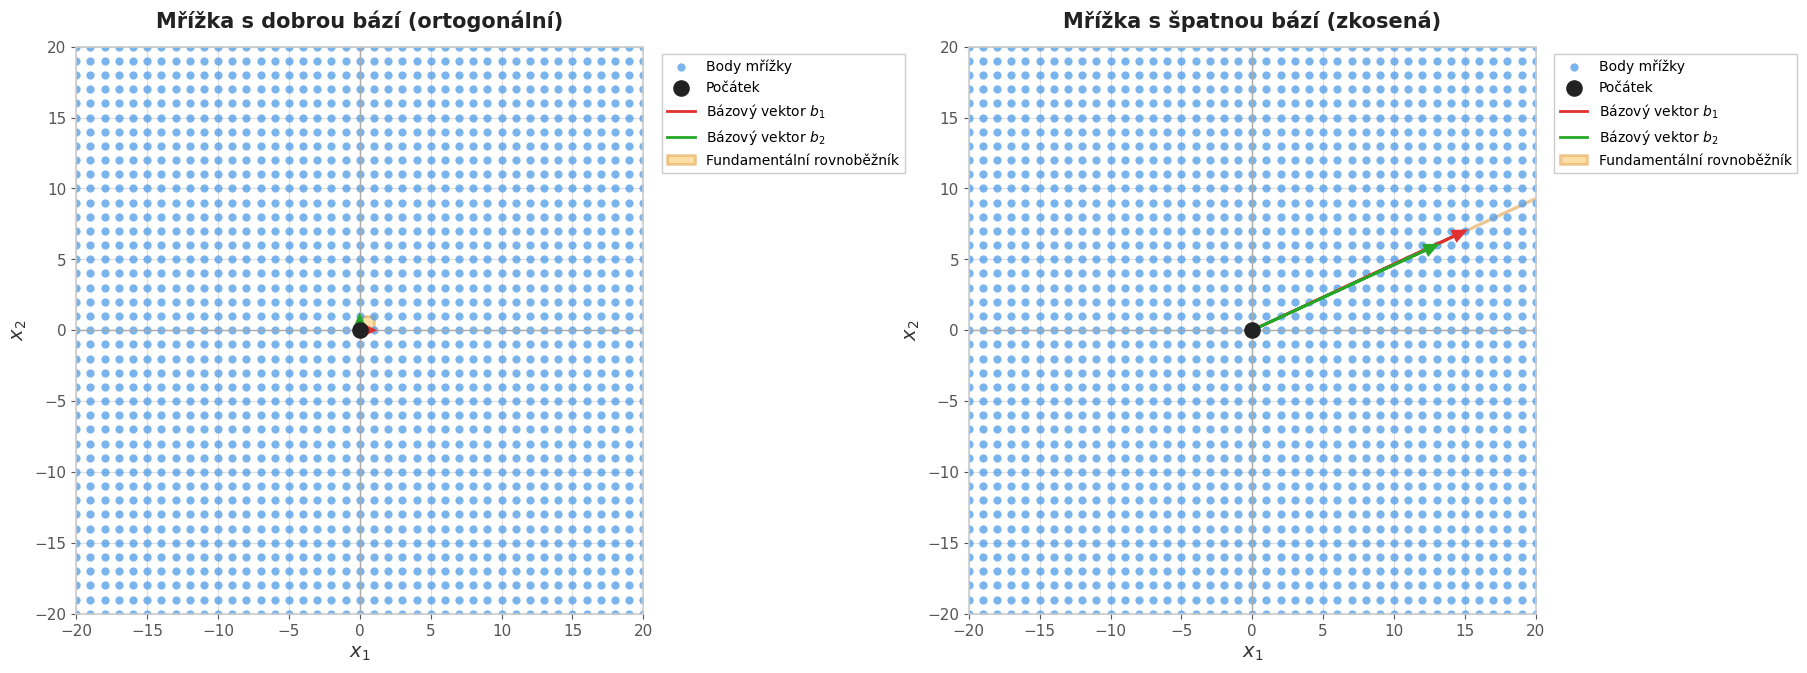


Vizualizace dokončena! Obě mřížky obsahují stejné body, ale s různými bázemi.


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Vykreslení dobré báze
plot_lattice(B_good, "dobrou bází (ortogonální)", range_limit=5, ax=axes[0])

# Vykreslení špatné báze
plot_lattice(B_bad, "špatnou bází (zkosená)", range_limit=5, ax=axes[1])

plt.tight_layout()
plt.show()

print("\nVizualizace dokončena! Obě mřížky obsahují stejné body, ale s různými bázemi.")

## Simulace problému nejbližšího vektoru (CVP)

Implementace Babaiova algoritmu nejbližší roviny (round-off přístup) pro řešení CVP.

### Babaiův algoritmus:

Dán cílový vektor $\mathbf{t}$ a báze $B$:

1. Vypočítat koeficienty: $\mathbf{c} = B^{-1} \cdot \mathbf{t}$
2. Zaokrouhlit koeficienty: $\mathbf{c}' = \text{round}(\mathbf{c})$
3. Najít nejbližší bod: $\mathbf{v} = B \cdot \mathbf{c}'$

**Klíčové pozorování:** Algoritmus funguje dobře s ortogonální bází, ale selává se zkosenou bází.

In [51]:
def babai_nearest_plane(target, basis):
    """
    Babaiův algoritmus nejbližší roviny (round-off přístup) pro CVP.
    
    Tento algoritmus poskytuje aproximaci řešení CVP zaokrouhlením
    souřadnic cílového vektoru v bázi mřížky.
    
    Parametry:
    -----------
    target : numpy.ndarray
        Cílový bod (zašuměná zpráva)
    basis : numpy.ndarray
        Matice 2x2 reprezentující bázi mřížky
    
    Návratová hodnota:
    ------------------
    tuple : (closest_point, coefficients)
        closest_point : odhadovaný nejbližší bod mřížky
        coefficients : zaokrouhlené koeficienty
    """
    # Krok 1: Vyjádření cílového bodu v souřadnicích báze
    basis_inv = np.linalg.inv(basis)
    coefficients = basis_inv @ target
    
    # Krok 2: Zaokrouhlení na nejbližší celá čísla
    rounded_coeffs = np.round(coefficients)
    
    # Krok 3: Převod zpět do kartézských souřadnic
    closest_point = basis @ rounded_coeffs
    
    return closest_point, rounded_coeffs

def find_true_closest_point(target, lattice_points):
    """
    Hrubou silou nalezení skutečně nejbližšího bodu mřížky.
    
    Tato funkce slouží jako referenční řešení pro ověření
    správnosti Babaiova algoritmu.
    
    Parametry:
    -----------
    target : numpy.ndarray
        Cílový bod
    lattice_points : numpy.ndarray
        Pole všech bodů mřížky
    
    Návratová hodnota:
    ------------------
    numpy.ndarray
        Skutečně nejbližší bod mřížky
    """
    distances = np.linalg.norm(lattice_points - target, axis=1)
    closest_idx = np.argmin(distances)
    return lattice_points[closest_idx]

# Generování náhodného cílového bodu, který NENÍ na mřížce
# Pro demonstraci použijeme bod s neceločíselnými souřadnicemi
t = np.array([2.7, 3.3])

print("=== Cílový bod (zašuměná zpráva) ===")
print(f"t = {t}")

# Řešení CVP s použitím dobré báze
closest_good, coeffs_good = babai_nearest_plane(t, B_good)
print("\n=== Řešení CVP s dobrou bází ===")
print(f"Zaokrouhlené koeficienty: {coeffs_good}")
print(f"Odhadovaný nejbližší bod: {closest_good}")
print(f"Vzdálenost k cíli: {np.linalg.norm(t - closest_good):.4f}")

# Řešení CVP s použitím špatné báze
closest_bad, coeffs_bad = babai_nearest_plane(t, B_bad)
print("\n=== Řešení CVP se špatnou bází ===")
print(f"Zaokrouhlené koeficienty: {coeffs_bad}")
print(f"Odhadovaný nejbližší bod: {closest_bad}")
print(f"Vzdálenost k cíli: {np.linalg.norm(t - closest_bad):.4f}")

# Nalezení skutečně nejbližšího bodu
lattice_points_good = generate_lattice_points(B_good, range_limit=10)
true_closest = find_true_closest_point(t, lattice_points_good)
print("\n=== Skutečně nejbližší bod (hrubá síla) ===")
print(f"Skutečně nejbližší bod: {true_closest}")
print(f"Vzdálenost k cíli: {np.linalg.norm(t - true_closest):.4f}")

# Kontrola správnosti
print("\n=== Výsledky ===")
print(f"Dobrá báze nalezne správné řešení: {'ANO' if np.allclose(closest_good, true_closest) else 'NE'}")
print(f"Špatná báze nalezne správné řešení: {'ANO' if np.allclose(closest_bad, true_closest) else 'NE'}")
print(f"\nChyba se špatnou bází: {np.linalg.norm(closest_bad - true_closest):.4f}")

=== Cílový bod (zašuměná zpráva) ===
t = [2.7 3.3]

=== Řešení CVP s dobrou bází ===
Zaokrouhlené koeficienty: [3. 3.]
Odhadovaný nejbližší bod: [3. 3.]
Vzdálenost k cíli: 0.4243

=== Řešení CVP se špatnou bází ===
Zaokrouhlené koeficienty: [  7. -14.]
Odhadovaný nejbližší bod: [7. 7.]
Vzdálenost k cíli: 5.6727

=== Skutečně nejbližší bod (hrubá síla) ===
Skutečně nejbližší bod: [3. 3.]
Vzdálenost k cíli: 0.4243

=== Výsledky ===
Dobrá báze nalezne správné řešení: ANO
Špatná báze nalezne správné řešení: NE

Chyba se špatnou bází: 5.6569


## Testování s více cílovými body

Otestování CVP s více náhodnými cílovými body pro demonstraci konzistence problému.

In [52]:
# Test s více náhodnými cílovými body
num_tests = 10
np.random.seed(41)

results_good = []
results_bad = []

print("Testování CVP s více náhodnými cílovými body...\n")
print(f"{'Cílový bod':<20} {'Dobrá báze':<15} {'Špatná báze':<15} {'Demonstruje problém'}")
print("-" * 75)

for i in range(num_tests):
    # Generování náhodného cílového bodu v rozsahu [-5, 5] s neceločíselnými souřadnicemi
    target = np.random.uniform(-4, 4, size=2)
    
    # Řešení CVP
    closest_good, _ = babai_nearest_plane(target, B_good)
    closest_bad, _ = babai_nearest_plane(target, B_bad)
    
    # Nalezení skutečně nejbližšího
    true_closest = find_true_closest_point(target, lattice_points_good)
    
    # Kontrola, zda jsou řešení správná
    good_correct = np.allclose(closest_good, true_closest)
    bad_correct = np.allclose(closest_bad, true_closest)
    
    results_good.append(good_correct)
    results_bad.append(bad_correct)
    
    demonstrates_issue = good_correct and not bad_correct
    print(f"{str(target):<20} {'ANO' if good_correct else 'NE':<15} {'ANO' if bad_correct else 'NE':<15} {'ANO' if demonstrates_issue else 'NE'}")

print("-" * 75)
print(f"\nÚspěšnost dobré báze: {sum(results_good)/num_tests*100:.0f}% ({sum(results_good)}/{num_tests})")
print(f"Úspěšnost špatné báze: {sum(results_bad)/num_tests*100:.0f}% ({sum(results_bad)}/{num_tests})")
print(f"\nZávěr: Dobrá báze konzistentně řeší CVP správně, zatímco špatná báze často selhává.")
print(f"       Tato asymetrie je fundamentem bezpečnosti kryptografie založené na mřížkách.")

Testování CVP s více náhodnými cílovými body...

Cílový bod           Dobrá báze      Špatná báze     Demonstruje problém
---------------------------------------------------------------------------
[-1.99261101 -3.63123343] ANO             NE              ANO
[ 1.41452993 -3.65224411] ANO             ANO             NE
[-3.06861037  0.83092551] ANO             NE              ANO
[-2.4725547   1.34812574] ANO             NE              ANO
[ 3.33958279 -0.6497593 ] ANO             NE              ANO
[-1.3419212  -1.73573092] ANO             NE              ANO
[-2.50974186 -1.46311624] ANO             NE              ANO
[-0.15065065 -3.44383626] ANO             NE              ANO
[ 1.63986057 -1.48258453] ANO             NE              ANO
[ 1.96225884 -0.81429763] ANO             NE              ANO
---------------------------------------------------------------------------

Úspěšnost dobré báze: 100% (10/10)
Úspěšnost špatné báze: 10% (1/10)

Závěr: Dobrá báze konzistentně řeší 